In [15]:
import pandas as pd
import scipy
from sklearn.linear_model import LogisticRegression

from geoai.utils_ds.PreProcessingOps import PreProcessingOperations
from geoai.utils_ml.ModelOps import ModelOperations
from geoai.utils_ds.VisualizeOps import VisualizeOperations
import pickle
model_ops = ModelOperations()
pre_ops = PreProcessingOperations()
vis_ops = VisualizeOperations()


In [2]:
X_train = pd.read_csv("csv_files/X_train_fe.csv")
X_test = pd.read_csv("csv_files/X_test_fe.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,373.5,519.5,389.0,3034.0,1991.0,0.772714,-0.207562,0.002342,139502.25,194033.25,...,4.661945,0.597087,-0.160386,0.001809,0.043082,-0.000486,0.000005,0,1,2


In [3]:
# scale the data
X_train_fe_scaled, X_test_fe_scaled = pre_ops.scale_to_minmax(X_train, X_test)
X_train_fe_scaled.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,0.01238,0.020718,0.023453,0.615321,0.141552,0.941447,0.12174,0.883081,0.001893,0.002796,...,0.903032,0.882198,0.253733,0.844985,0.404388,0.207416,0.779808,0.0,1.0,1.0


In [4]:
# apply_lda using 3 components
X_train_lda, X_test_lda = pre_ops.apply_lda(
    X_train_fe_scaled, y_train, X_test_fe_scaled, n_components=3
)    

d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Learning Curves

In [5]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

mean_acc, std_acc = model_ops.stratify_k_fold_cv(X_train_lda, y_train, 10, lr)

d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed w

Fold: 01, Acc.: 0.953
Fold: 02, Acc.: 0.927
Fold: 03, Acc.: 0.929
Fold: 04, Acc.: 0.954


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed w

Fold: 05, Acc.: 0.948
Fold: 06, Acc.: 0.949
Fold: 07, Acc.: 0.906
Fold: 08, Acc.: 0.943
Fold: 09, Acc.: 0.912
Fold: 10, Acc.: 0.949

CV accuracy: 0.937 +/- 0.016


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


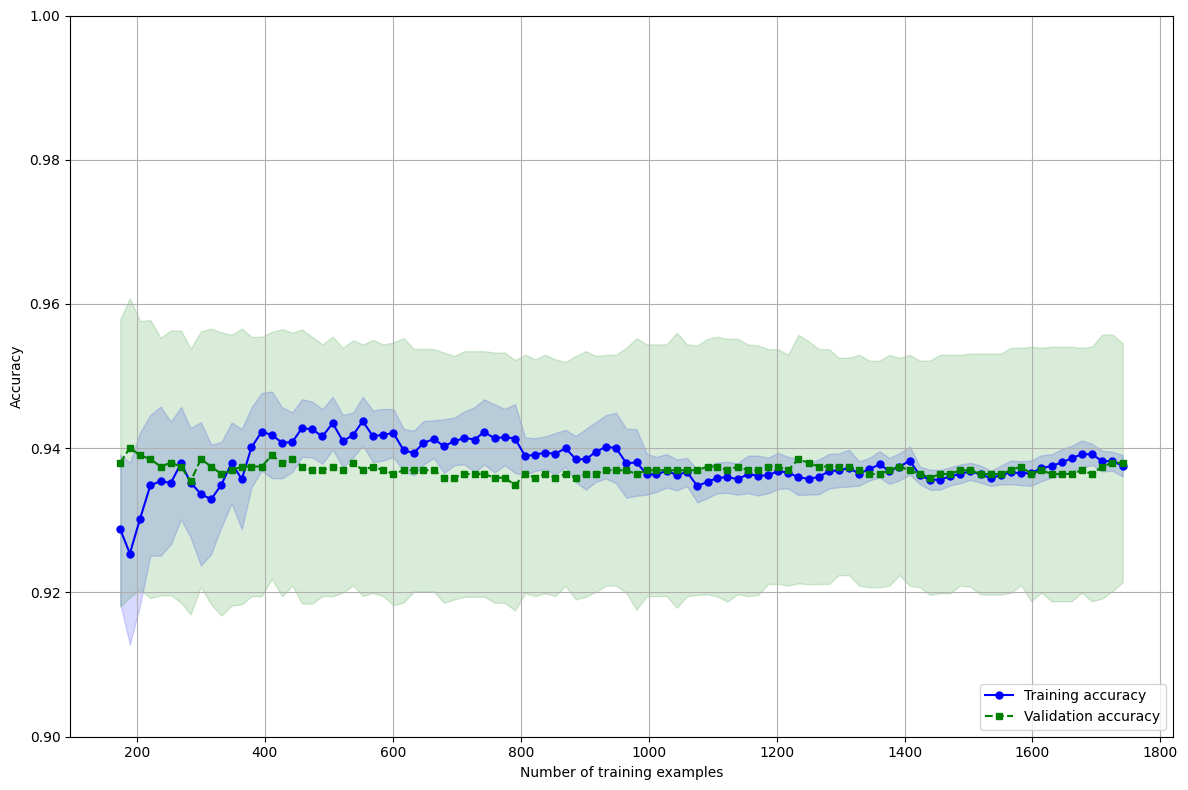

In [6]:
ylim = [0.9, 1.0]
train_sizes, train_mean, train_std, test_mean, test_std = model_ops.compute_metrics_for_learning_curve(X_train_lda, y_train, lr)
vis_ops.plot_learning_curve(train_sizes, train_mean, train_std, test_mean, test_std, ylim)

# Addressing over- and underfitting with validation curves

d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_cla

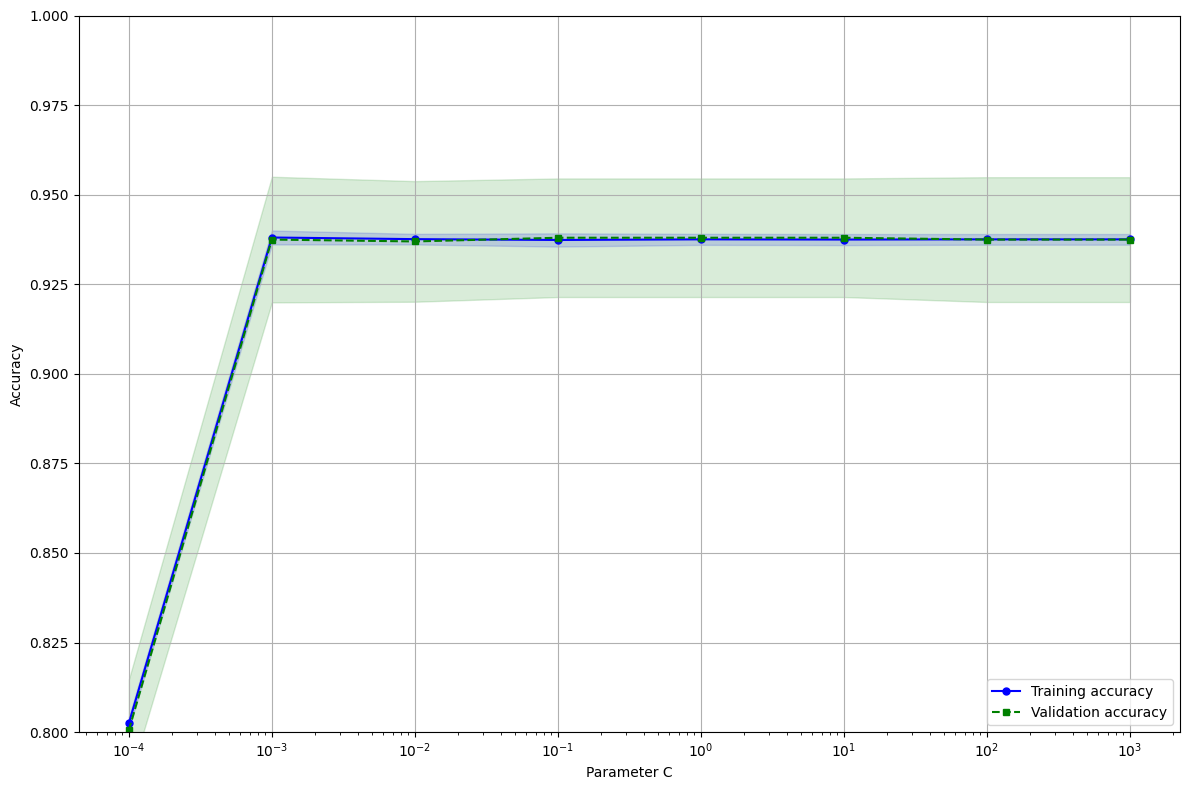

In [11]:
param_range = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_mean, train_std, test_mean, test_std = model_ops.compute_metric_for_validation_curve(
    X_train_lda, y_train, param_range, "C", lr
)
vis_ops.plot_validation_curve(
    param_range, train_mean, train_std, test_mean, test_std, 
)

# Tuning hyperparameters via grid search

In [9]:
lr = LogisticRegression(multi_class='auto')
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],
     'max_iter': [100, 200, 300, 400, 500],
}
best_params, best_score = model_ops.find_best_hyperparameters_gs(X_train_lda, y_train, lr, param_grid, "f1_weighted")
print(best_params, best_score)


{'C': 0.1, 'max_iter': 100, 'solver': 'newton-cg'} 0.9380939918882565


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# Tuning hyperparameters via randomized search

In [10]:
param_grid = {
    'C': scipy.stats.loguniform(0.01, 1000.0),
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],
     'max_iter': list(range(100, 510, 10)),
}
best_params, best_score = model_ops.find_best_hyperparameters_rs(X_train_lda, y_train, lr, param_grid, "f1_weighted")
print(best_params, best_score)

{'C': 9.232675920286502, 'max_iter': 160, 'solver': 'lbfgs'} 0.9386044668377418


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# Find the final accuracy of the model

In [13]:
best_params = {'C': 9.232675920286502, 'max_iter': 160, 'solver': 'lbfgs'}
lr_optimized = LogisticRegression(**best_params)

lr_optimized.fit(X_train_lda, y_train)
y_train_pred = lr_optimized.predict(X_train_lda)
y_pred_test = lr_optimized.predict(X_test_lda)

# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)}")

Train Accuracy: (0.937467700258398, 0.9378469707503807, 0.937467700258398, 0.9375970119680029)
Test Accuracy: (0.9256198347107438, 0.9265542124090291, 0.9256198347107438, 0.9258873031024559)


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


END